In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import pickle
import joblib

%matplotlib inline

## 1. Load Dataset

In [10]:
df = pd.read_csv('fraud_oracle.csv')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (15420, 33)


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


## 2. Clean Data

In [11]:
print('Duplicates before:', df.duplicated().sum())
df = df.drop_duplicates()
print('Duplicates after:', df.duplicated().sum())

print('\nMissing values before:', df.isnull().sum().sum())
df = df.dropna()
print('Missing values after:', df.isnull().sum().sum())
print('Cleaned shape:', df.shape)

Duplicates before: 0
Duplicates after: 0

Missing values before: 0
Missing values after: 0
Cleaned shape: (15420, 33)


## 3. Feature Preparation

Encoded feature shape: (15420, 122)
Fraud rate: 0.05985732814526589


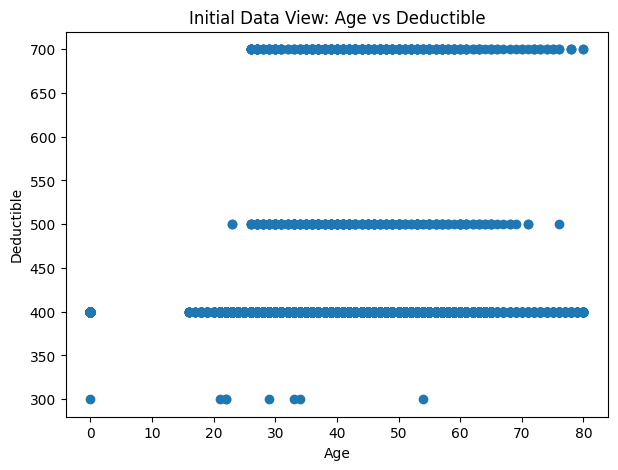

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    df.head()
except NameError:
    df = pd.read_csv('fraud_oracle.csv')

target = df['FraudFound_P']
feature_source = df.drop(['FraudFound_P', 'PolicyNumber', 'RepNumber'], axis=1)

categorical_cols = feature_source.select_dtypes(include=['object', 'string']).columns
X = pd.get_dummies(feature_source, columns=categorical_cols, drop_first=True)

print('Encoded feature shape:', X.shape)
print('Fraud rate:', target.mean())

plt.figure(figsize=(7, 5))
plt.scatter(df['Age'], df['Deductible'])
plt.xlabel('Age')
plt.ylabel('Deductible')
plt.title('Initial Data View: Age vs Deductible')
plt.show()

## 4. Split and Scale Features

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train shape:', X_train_scaled.shape)
print('Test shape:', X_test_scaled.shape)

Train shape: (12336, 122)
Test shape: (3084, 122)


## 5. Elbow Plot

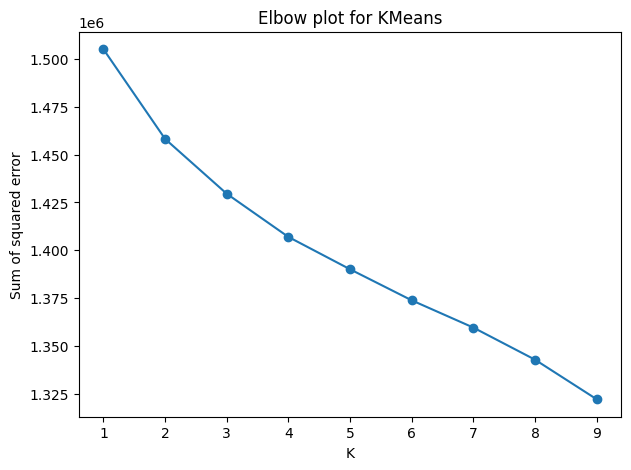

In [14]:
sse = []
k_rng = range(1, 10)

for k in k_rng:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_scaled)
    sse.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(k_rng, sse, marker='o')
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.title('Elbow plot for KMeans')
plt.show()

## 6. Train KMeans With Different Parameters

In [15]:
def map_clusters_to_labels(cluster_ids, true_labels):
    mapping = {}
    for cluster_id in np.unique(cluster_ids):
        cluster_mask = cluster_ids == cluster_id
        majority_label = pd.Series(true_labels[cluster_mask]).mode()[0]
        mapping[cluster_id] = int(majority_label)
    return mapping

best_k = None
best_accuracy = -1
best_model = None
best_mapping = None
best_predictions = None

for k in [2, 3, 4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    train_clusters = km.fit_predict(X_train_scaled)
    mapping = map_clusters_to_labels(train_clusters, y_train.to_numpy())
    test_clusters = km.predict(X_test_scaled)
    preds = np.array([mapping[c] for c in test_clusters])
    acc = accuracy_score(y_test, preds)
    print(f'k={k}, accuracy={acc}')
    if acc > best_accuracy:
        best_k = k
        best_accuracy = acc
        best_model = km
        best_mapping = mapping
        best_predictions = preds

print('Best k:', best_k)
print('Best accuracy:', best_accuracy)
print('Best mapping:', best_mapping)

k=2, accuracy=0.9400129701686122
k=3, accuracy=0.9400129701686122
k=4, accuracy=0.9400129701686122
k=5, accuracy=0.9400129701686122
k=6, accuracy=0.9400129701686122
Best k: 2
Best accuracy: 0.9400129701686122
Best mapping: {np.int32(0): 0, np.int32(1): 0}


## 7. Predict and Evaluate

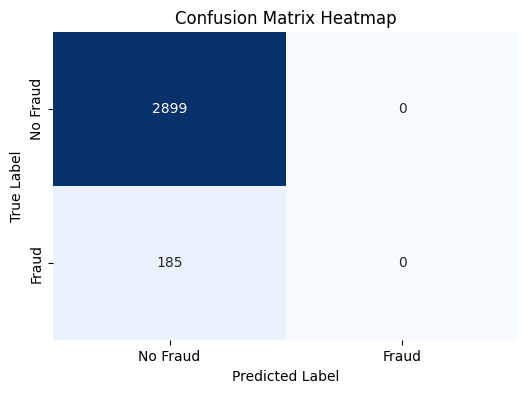

Best Parameters - k: 2
Final Best Accuracy: 0.9400

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.00      0.00      0.00       185

    accuracy                           0.94      3084
   macro avg       0.47      0.50      0.48      3084
weighted avg       0.88      0.94      0.91      3084



In [16]:
cm = confusion_matrix(y_test, best_predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Fraud', 'Fraud'], yticklabels=['No Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

print(f'Best Parameters - k: {best_k}')
print(f'Final Best Accuracy: {accuracy_score(y_test, best_predictions):.4f}')
print("\nClassification Report:\n", classification_report(y_test, best_predictions, zero_division=0))

## 8. Save Model

In [17]:
model_bundle = {
    'model': best_model,
    'scaler': scaler,
    'feature_columns': X.columns.tolist(),
    'cluster_to_label': best_mapping,
    'best_k': best_k,
    'label_names': {0: 'Low-risk claim', 1: 'High-risk claim'}
}

with open('riskproof_kmeans.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

joblib.dump(model_bundle, 'riskproof_kmeans.joblib')
print('Saved model files: riskproof_kmeans.pkl and riskproof_kmeans.joblib')

Saved model files: riskproof_kmeans.pkl and riskproof_kmeans.joblib
